<a href="https://colab.research.google.com/github/fatahirli24/-ENCE_3503_Fall_2024_EDA_Team_27.ipynb/blob/main/ENCE_3503_Fall_2024_EDA_Team_27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving scraped_data_team_27.csv to scraped_data_team_27.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath = "/content/scraped_data_team_27.csv" # update this line
buildings = pd.read_csv(filepath)

In [ ]:
buildings.head(3)

,date,price,description,location,area,renovated,number_of_floor,number_of_rooms,documents,category
0,"10.12.2024, 16:59",146 000 AZN,"['Minsk layihəli, super təmirli mənzil satılır...","Bakı şəhəri, Nərimanov r., K.Rəhimov küç.",80 m²,True,5 / 5,3,True,Köhnə tikili
1,"10.12.2024, 17:00",260 000 AZN,['ƏLA FÜRSƏT İDEAL TƏKLİF 🔥 BAKININ ƏN PRESTİJ...,"Bakı şəhəri, Yasamal r., İ.Qutqaşınlı küç",105 m²,True,3 / 12,3,True,Yeni tikili
2,"10.12.2024, 16:52",328 560 AZN,['Ahmadli Park Premium Yaşayış Kompleksi'],"Bakı şəhəri, Xətai r., Babək pr., Babək Plaza",222 m²,False,3 / 13,4,False,Yeni tikili


In [ ]:
buildings.isnull().sum() # checking if there is any column that contains some null values

,0
date,0
price,0
description,0
location,32
area,0
renovated,0
number_of_floor,0
number_of_rooms,0
documents,0
category,0


In [ ]:
buildings['location']=buildings['location'].fillna(0) # getting rid of the null values via replacing them with 0

In [ ]:
buildings.isnull().sum() # checking again

,0
date,0
price,0
description,0
location,0
area,0
renovated,0
number_of_floor,0
number_of_rooms,0
documents,0
category,0


In [ ]:
buildings['price'] = buildings['price'].str.replace(' ', '').str.replace('AZN', '').astype(int) #we're refining the values of price column, so that we can analyse the data neatly: getting rid of AZN and spaces between digits, converting to integer at last
buildings['area'] = buildings['area'].str.replace(' ', '').str.replace('m²', '').astype(float) #we're refining the values of area column, so that we can analyse the data neatly: getting rid of m² and spaces, converting to float at last




In [ ]:
buildings[['floor', 'total_floors']] = buildings['number_of_floor'].str.split('/', expand=True) #we seperated the number_of_floor column into these columns so that we can do data analysis more neatly. You'll see the demonstartion in latter parts
buildings['floor'] = buildings['floor'].astype(int) #conversion to integer
buildings['total_floors'] = buildings['total_floors'].astype(int) #conversion to integer

In [ ]:
buildings = buildings.drop(columns=['number_of_floor']) #now that we don't need unseperated column, we drop it to have clearer vision of data

In [ ]:
buildings.describe()

,price,area,number_of_rooms,floor,total_floors
count,1.680000e+02,168.00000,168.000000,168.000000,168.000000
mean,2.575173e+05,95.58869,2.672619,7.619048,13.214286
std,1.980773e+05,41.86923,0.807873,5.000371,5.969125
min,4.699900e+04,30.00000,1.000000,1.000000,2.000000
25%,1.546250e+05,65.00000,2.000000,4.000000,9.000000
50%,2.085000e+05,85.50000,3.000000,6.500000,14.000000
75%,2.967500e+05,118.50000,3.000000,11.000000,17.000000
max,1.938000e+06,235.00000,5.000000,27.000000,33.000000


In [ ]:
buildings['date'] = pd.to_datetime(buildings['date'], format='%d.%m.%Y, %H:%M') #converting the date column to  appropiate datetime format of pandas to perform neat data analysis

In [ ]:
buildings.info() #checking the data types of columns and see if there are any missing points in values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             168 non-null    datetime64[ns]
 1   price            168 non-null    int64         
 2   description      168 non-null    object        
 3   location         168 non-null    object        
 4   area             168 non-null    float64       
 5   renovated        168 non-null    bool          
 6   number_of_rooms  168 non-null    int64         
 7   documents        168 non-null    bool          
 8   category         168 non-null    object        
 9   floor            168 non-null    int64         
 10  total_floors     168 non-null    int64         
dtypes: bool(2), datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 12.3+ KB


In [ ]:

# Ensuring the 'date' column is parsed as datetime to analyze listing dates
buildings['date'] = pd.to_datetime(buildings['date'], errors='coerce')

# Sorting by the 'date' column to find the oldest listings
oldest_properties = buildings.sort_values('date').head()

oldest_properties


,date,price,description,location,area,renovated,number_of_rooms,documents,category,floor,total_floors
92,2024-12-10 16:44:00,138000,"['Bakıxanov Razin. Tam Mərkəzdə, Bazarstor Bey...","Bakı şəhəri, Bakıxanov q., Sakit Qocayev küç. ...",49.0,True,2,True,Yeni tikili,9,12
97,2024-12-10 16:44:00,213000,"['Yasamal qəsəbəsində,20 Yanvar metrosuna 10 d...","Bakı şəhəri, Nərimanov r., Təbriz küç.",110.0,True,4,True,Köhnə tikili,2,9
36,2024-12-10 16:44:00,752000,['Park Kvartalında dəniz mənzərəli ORJİNAL 4 O...,"Bakı şəhəri, Xətai r., Babək pr.",194.0,False,4,False,Yeni tikili,7,22
143,2024-12-10 16:44:00,225000,['Xalqlar metrosu yaxınlığında yerləşən 🌟 komp...,"Bakı şəhəri, Binəqədi r., Z. Bünyadov pr. 19",108.0,True,3,True,Yeni tikili,7,19
75,2024-12-10 16:44:00,1938000,['Crescent Residences – Bakının Mərkəzində Lük...,0,201.0,False,3,False,Yeni tikili,9,33


In [ ]:
# Function to find the most expensive property in each location (district)
def expensive_location(buildings):
    return buildings.loc[buildings.groupby('location')['price'].idxmax()]
top_location = expensive_location(buildings)
top_location


,date,price,description,location,area,renovated,number_of_rooms,documents,category,floor,total_floors
75,2024-12-10 16:44:00,1938000,['Crescent Residences – Bakının Mərkəzində Lük...,0,201.0,False,3,False,Yeni tikili,9,33
120,2024-12-10 17:11:00,310000,['Premium Bina Baku Panorama Residance 3 otaql...,"Bakı şəhəri, Xətai r., A.İsmayılov küç. (Ruse...",95.0,True,3,False,Yeni tikili,10,16
71,2024-12-10 17:02:00,370000,"['📌 S A T I L I R ✨', '✔Yeni tikil binada QANU...","Bakı şəhəri, Bakı ş., Nərimanov r., F. Yusifov...",143.0,False,3,True,Yeni tikili,5,17
92,2024-12-10 16:44:00,138000,"['Bakıxanov Razin. Tam Mərkəzdə, Bazarstor Bey...","Bakı şəhəri, Bakıxanov q., Sakit Qocayev küç. ...",49.0,True,2,True,Yeni tikili,9,12
147,2024-12-10 16:59:00,153000,['Təcili satilir ..............menzil.qaz su i...,"Bakı şəhəri, Binəqədi r., S. S. Axundov küç.",68.0,True,3,True,Köhnə tikili,3,9
143,2024-12-10 16:44:00,225000,['Xalqlar metrosu yaxınlığında yerləşən 🌟 komp...,"Bakı şəhəri, Binəqədi r., Z. Bünyadov pr. 19",108.0,True,3,True,Yeni tikili,7,19
82,2024-12-10 16:59:00,240000,"['TECILI,QAZLI,KUPCALI!!!Baki seheri Nerimanov...","Bakı şəhəri, Binəqədi r., İ.Dadaşov küç. 167",77.0,True,2,True,Yeni tikili,9,16
53,2024-12-10 16:46:00,230000,['Mənzil Heydər Əliyev mərkəzinin yanında yeni...,"Bakı şəhəri, Nizami r., Heydər Əliyev pr. (Çin...",95.0,False,2,False,Yeni tikili,8,16
116,2024-12-10 17:08:00,850000,['Ağ Şəhər 1-ci Yaşıl ada küçəsi dənizə panara...,"Bakı şəhəri, Nizami r., Q.Qarayev pr. 77",214.0,True,5,True,Yeni tikili,5,7
9,2024-12-10 16:57:00,145000,['TECILI;;Yeni Gunesli Qesebesi Q Massivi Azpe...,"Bakı şəhəri, Nizami r., Ə.Hacıyev küç. 23a (""Q...",115.0,True,5,True,Köhnə tikili,8,9


In [ ]:

def expensive_characteristics(buildings, category, N):
    filtered_buildings = buildings[buildings['category'] == category]
    return filtered_buildings.nlargest(N, 'price')


# Finding the top 5 most expensive properties in the "Yeni tikili" category
top = expensive_characteristics(buildings, category="Yeni tikili", N=4)



top


,date,price,description,location,area,renovated,number_of_rooms,documents,category,floor,total_floors
75,2024-12-10 16:44:00,1938000,['Crescent Residences – Bakının Mərkəzində Lük...,0,201.0,False,3,False,Yeni tikili,9,33
124,2024-12-10 16:46:00,1224000,['Crescent Residences – Bakının Mərkəzində Lük...,0,97.8,False,2,False,Yeni tikili,20,33
116,2024-12-10 17:08:00,850000,['Ağ Şəhər 1-ci Yaşıl ada küçəsi dənizə panara...,"Bakı şəhəri, Nizami r., Q.Qarayev pr. 77",214.0,True,5,True,Yeni tikili,5,7
36,2024-12-10 16:44:00,752000,['Park Kvartalında dəniz mənzərəli ORJİNAL 4 O...,"Bakı şəhəri, Xətai r., Babək pr.",194.0,False,4,False,Yeni tikili,7,22


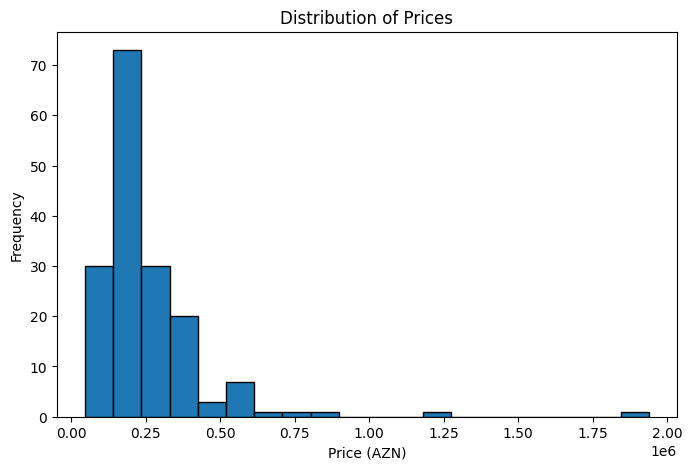

In [ ]:
# Distribution of prices
plt.figure(figsize=(8, 5))
plt.hist(buildings['price'], bins=20, edgecolor='black')
plt.title('Distribution of Prices')
plt.xlabel('Price (AZN)')
plt.ylabel('Frequency')
plt.show()

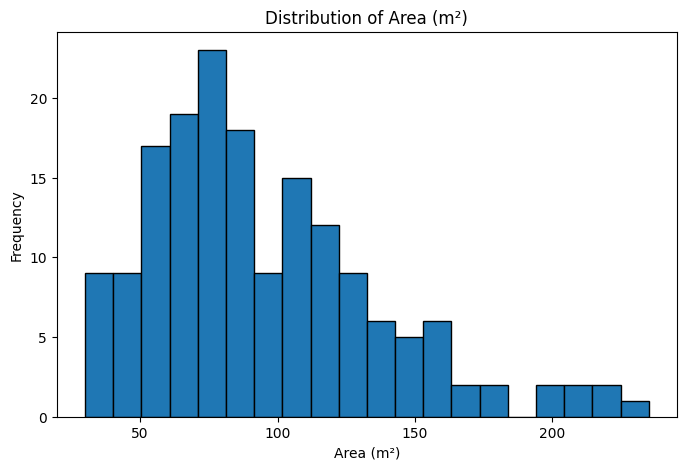

In [ ]:
# Distribution of area
plt.figure(figsize=(8, 5))
plt.hist(buildings['area'], bins=20, edgecolor='black')
plt.title('Distribution of Area (m²)')
plt.xlabel('Area (m²)')
plt.ylabel('Frequency')
plt.show()

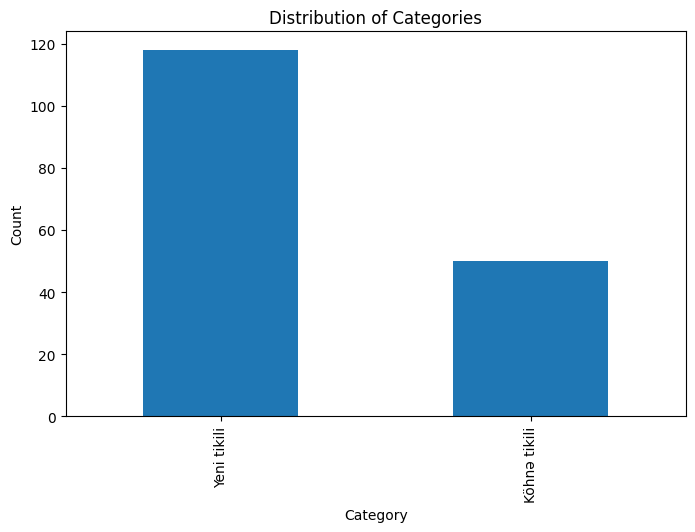

In [ ]:
# Category counts
category_counts = buildings['category'].value_counts()

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar')
plt.title('Distribution of Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

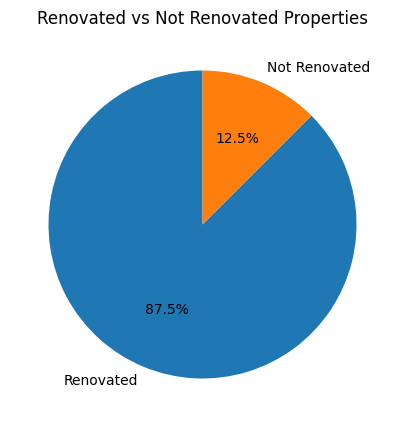

In [ ]:
# Renovated vs Not Renovated
renovated_counts = buildings['renovated'].value_counts()

plt.figure(figsize=(8, 5))
renovated_counts.plot(kind='pie', autopct='%1.1f%%', labels=['Renovated', 'Not Renovated'], startangle=90)
plt.title('Renovated vs Not Renovated Properties')
plt.ylabel('')
plt.show()

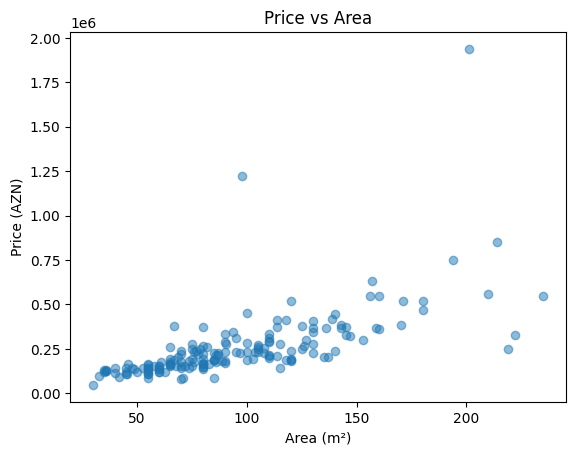

In [ ]:
# --- 5. Price vs Area Scatter Plot ---
plt.scatter(buildings['area'], buildings['price'], alpha=0.5)
plt.title('Price vs Area')
plt.xlabel('Area (m²)')
plt.ylabel('Price (AZN)')
plt.show()

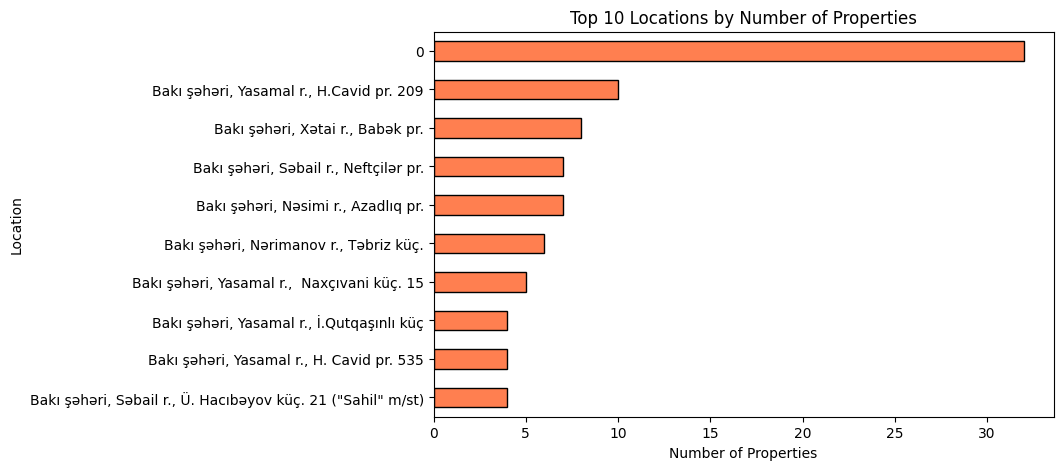

In [ ]:
# --- Top 10 Locations ---
top_locations = (
    buildings['location']
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)
plt.figure(figsize=(8, 5))
top_locations.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 10 Locations by Number of Properties')
plt.xlabel('Number of Properties')
plt.ylabel('Location')
plt.show()

In [ ]:
buildings.to_csv('processed_data_team_27.csv', index=False)